In [4]:
from spisea import synthetic, atmospheres, reddening, evolution
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os
import copy
import pandas as pd
from tqdm import tqdm
from filter_extinction import ext_utils
import pdb

In [5]:
%load_ext autoreload
%autoreload 2

# Set up the ExtinctionCoefficientFitter
First, the fitter object will generate or load a grid of stellar colors and extinctions

In [3]:
roman_filters = ['roman,wfi,f062','roman,wfi,f087','roman,wfi,f106','roman,wfi,f129',
             'roman,wfi,f158','roman,wfi,f184','roman,wfi,f213','roman,wfi,f146']
ecf=0
# Compute extinction for all of Roman's filters, and exclude F146 from the color set
# This will use these defaults: A_Ks range of 0-5, [Fe/H]=0.0, and logg=[4.5, 2.0]
# If you change the A_Ks grid spacing, logg values, or filter sets, set recompute=True
ecf = ext_utils.ExtinctionCoefficientFitter(color_filter_list=roman_filters,
                                            ext_only_filter_list = ['euclid,vis'],
                                            #recompute_grid=True,
                                           )

For roman,wfi,f062, m_ab - m_vega = 0.1418860315199808
For roman,wfi,f087, m_ab - m_vega = 0.5069624249565408
For roman,wfi,f106, m_ab - m_vega = 0.6659690376827427
For roman,wfi,f129, m_ab - m_vega = 0.9739263057526699
For roman,wfi,f158, m_ab - m_vega = 1.3088682252670338
For roman,wfi,f184, m_ab - m_vega = 1.5764881750217157
For roman,wfi,f213, m_ab - m_vega = 1.8314297601129965
For roman,wfi,f146, m_ab - m_vega = 0.9703680920347395
For euclid,vis, m_ab - m_vega = 0.2563127244158494
Load or generate extinction + colors grid
Found saved file ./grids/ext_grid_met_0.00_AKs_5.00.h5


# Let's examine the magnitude of the issue
How extinction in each filter change with stellar type?

We also compare these to the values one would estimate if using the extinction law at a selected wavelength to represent the filter extinction (i.e. no dependence on stellar properties, constant A_lambda/A_Ks).

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f062_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f062_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


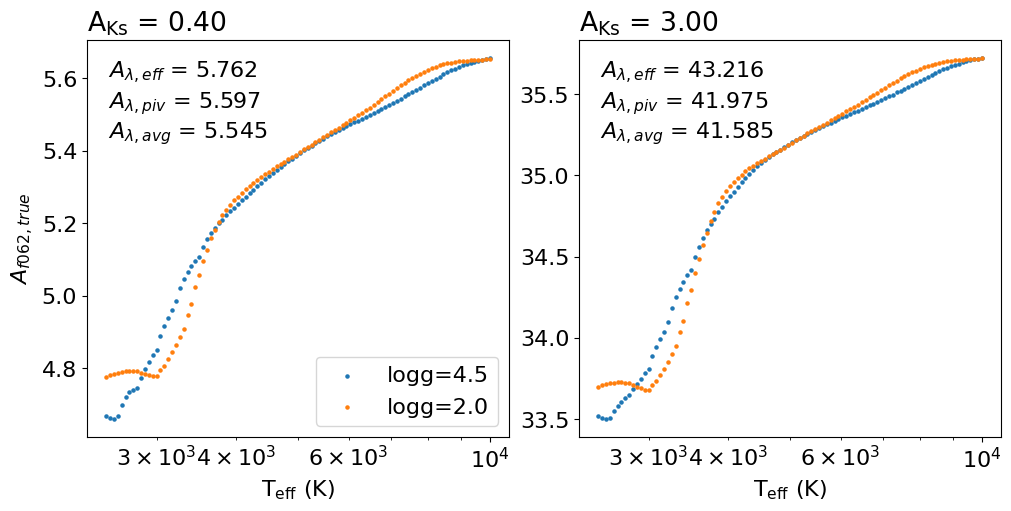

In [43]:
fig,ax = ecf.plot_true_extinction('f062', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f087_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f087_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


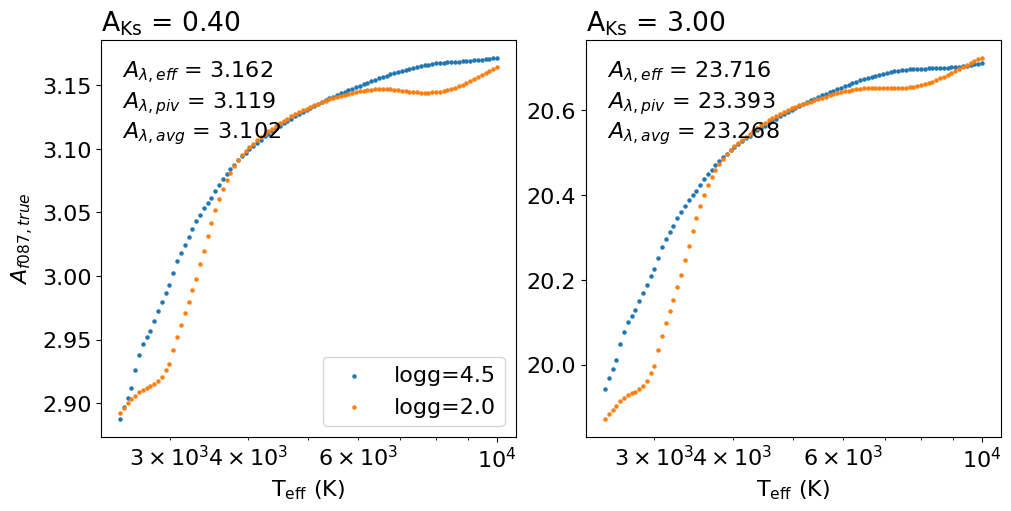

In [45]:
fig,ax = ecf.plot_true_extinction('f087', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f106_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f106_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


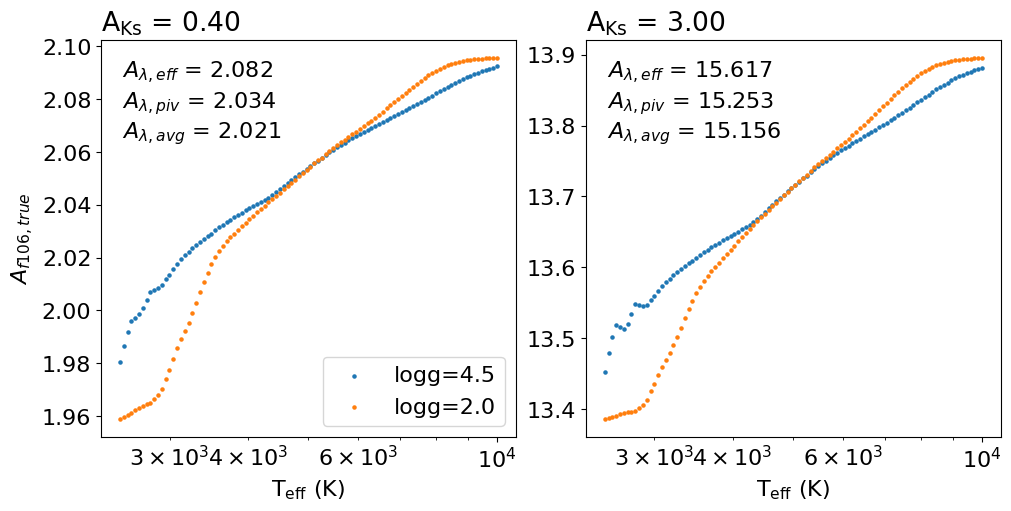

In [46]:
fig,ax = ecf.plot_true_extinction('f106', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f129_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f129_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


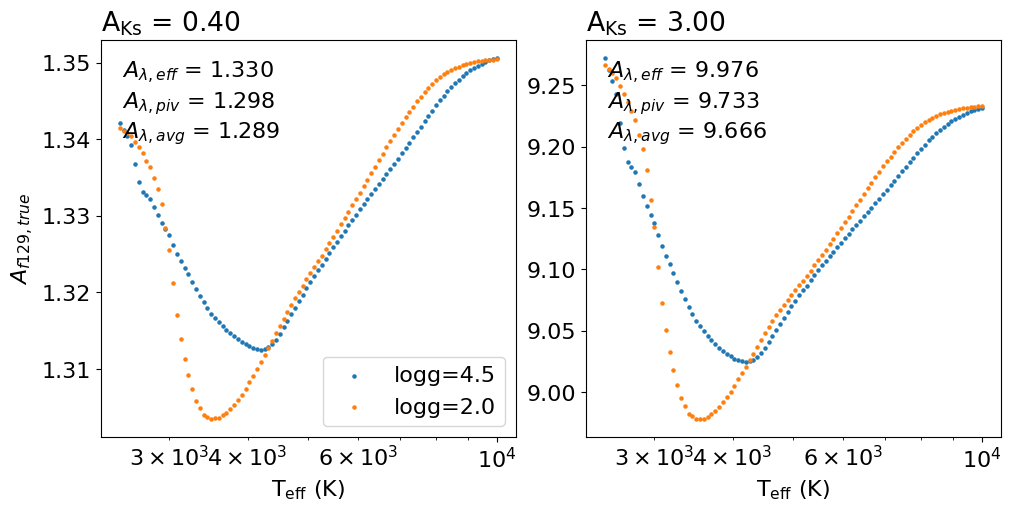

In [47]:
fig,ax = ecf.plot_true_extinction('f129', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f158_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f158_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


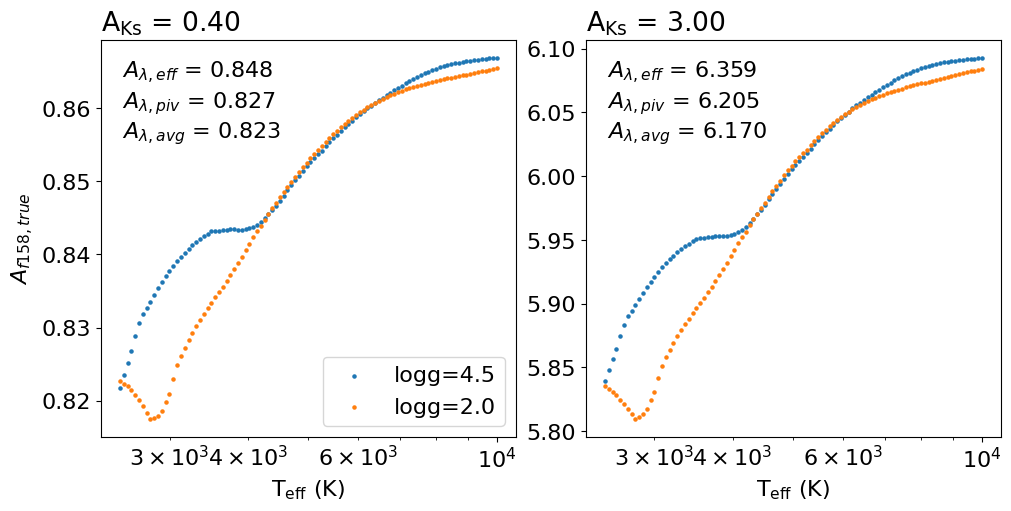

In [48]:
fig,ax = ecf.plot_true_extinction('f158', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f184_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f184_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


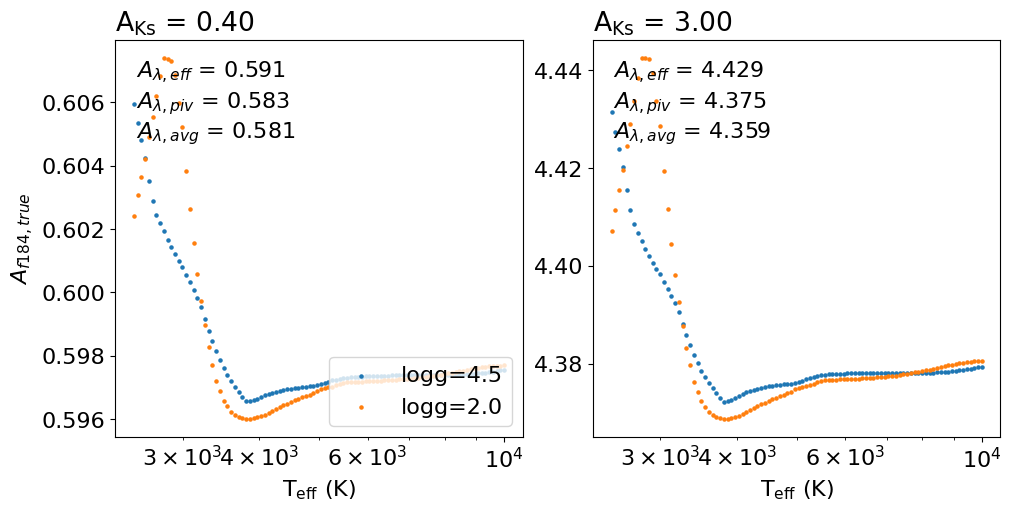

In [49]:
fig,ax = ecf.plot_true_extinction('f184', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f213_002_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f213_002_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


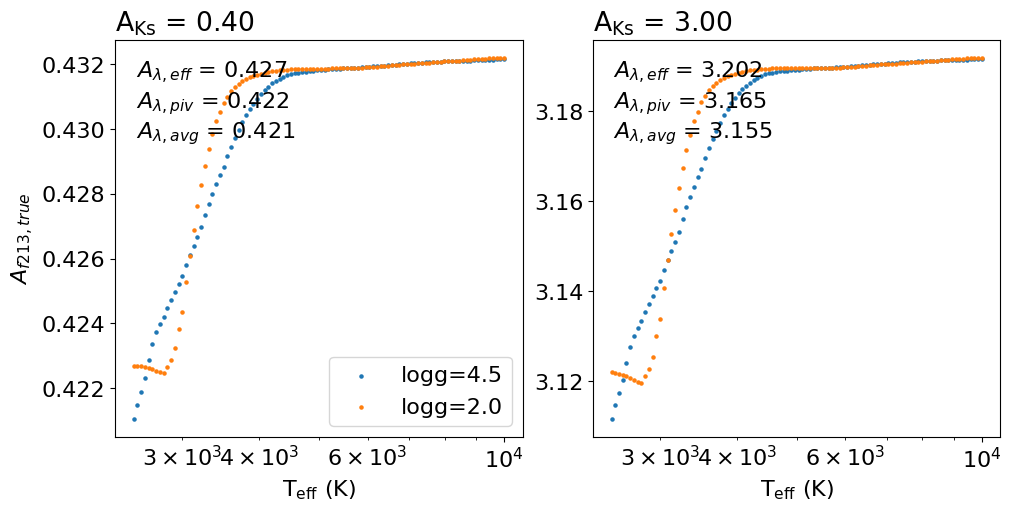

In [50]:
fig,ax = ecf.plot_true_extinction('f213', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f146_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f146_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


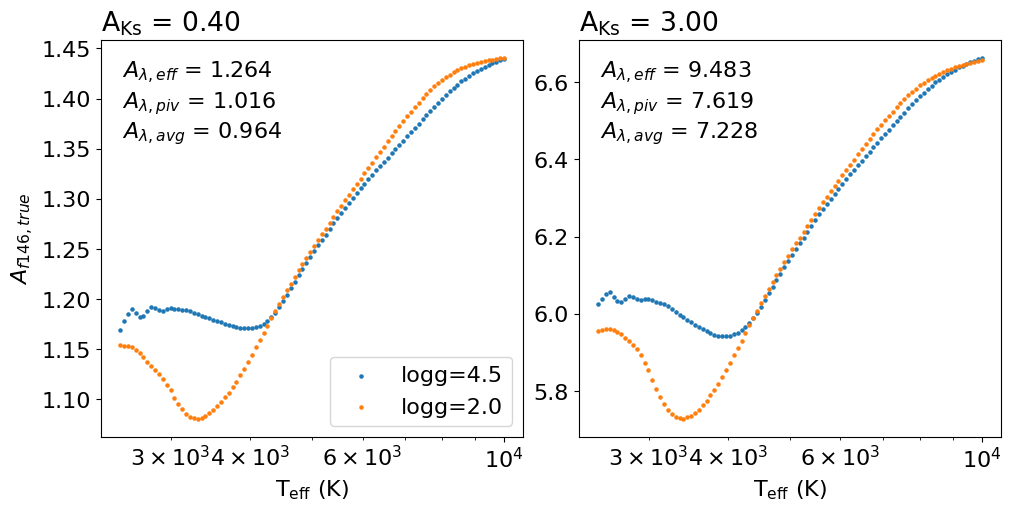

In [51]:
fig,ax = ecf.plot_true_extinction('f146', [0.4,3.0])

(euclid_vis) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(euclid_vis) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


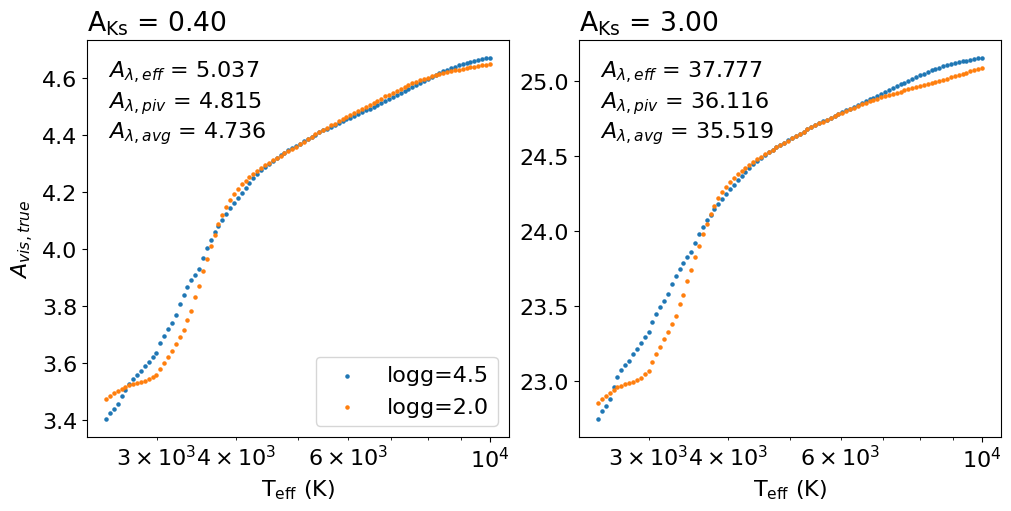

In [52]:
fig,ax = ecf.plot_true_extinction('vis', [0.4,3.0])

# How wrong are the typical Galactic model extinction estimations?

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f062_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f062_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


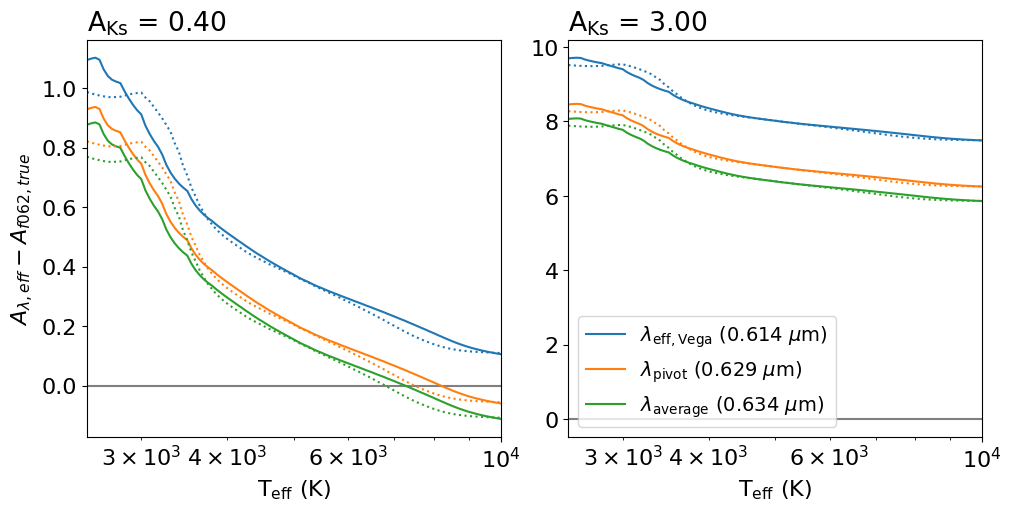

In [89]:
fig,ax = ecf.plot_extinction_difference('f062', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f087_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f087_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


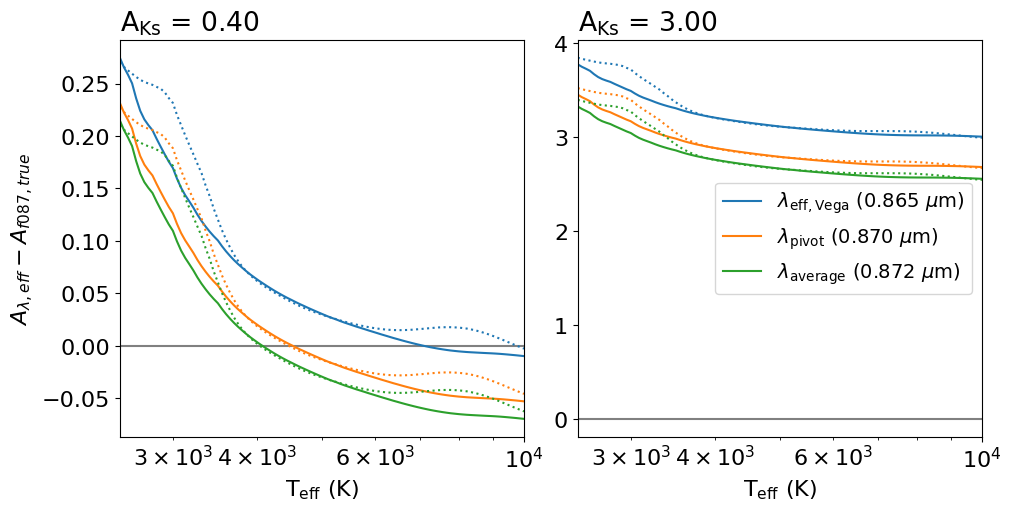

In [90]:
fig,ax = ecf.plot_extinction_difference('f087', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f106_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f106_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


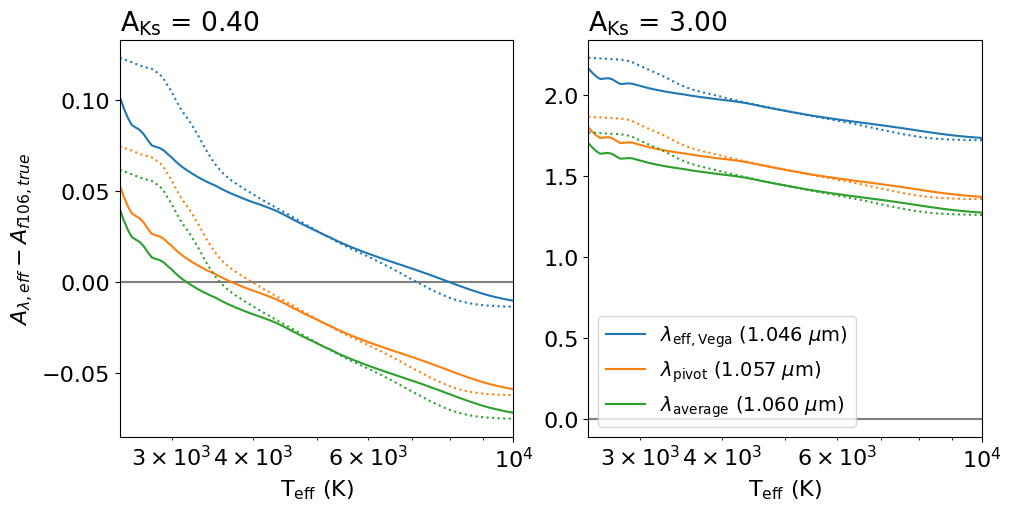

In [91]:
fig,ax = ecf.plot_extinction_difference('f106', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f129_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f129_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


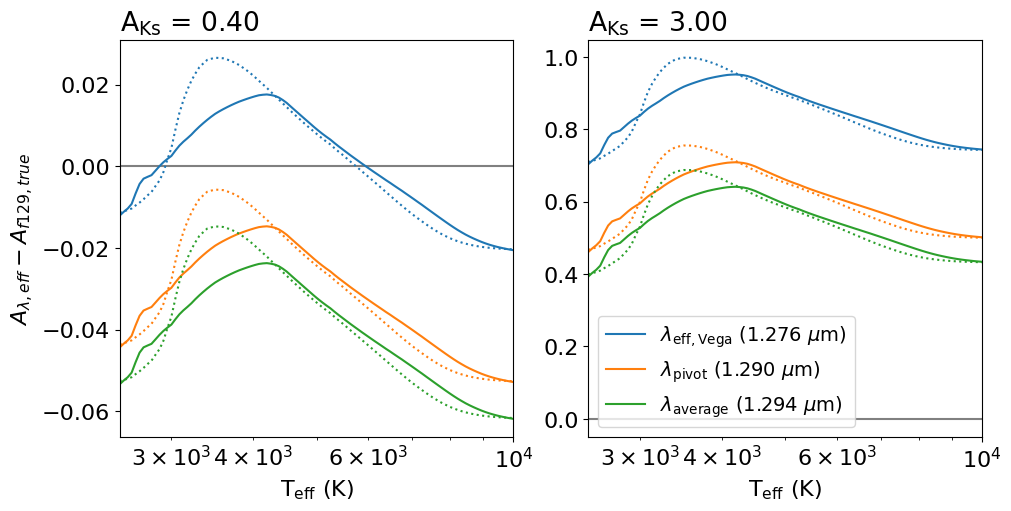

In [92]:
fig,ax = ecf.plot_extinction_difference('f129', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f158_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f158_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


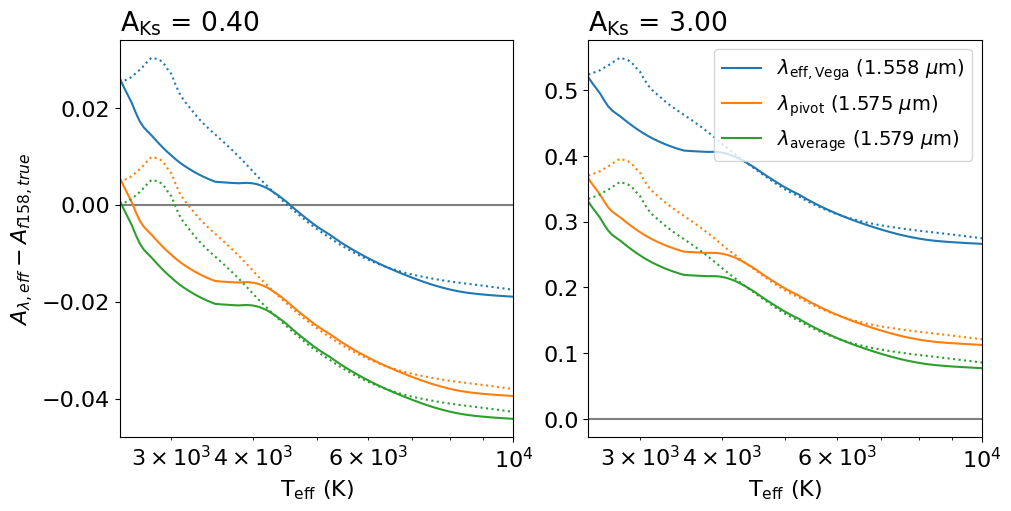

In [93]:
fig,ax = ecf.plot_extinction_difference('f158', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f184_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f184_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


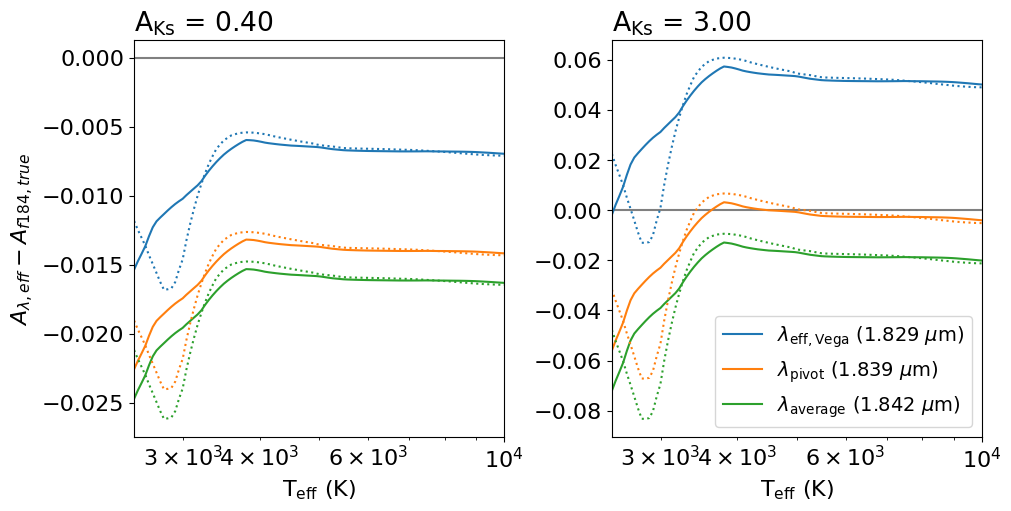

In [94]:
fig,ax = ecf.plot_extinction_difference('f184', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f213_002_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f213_002_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


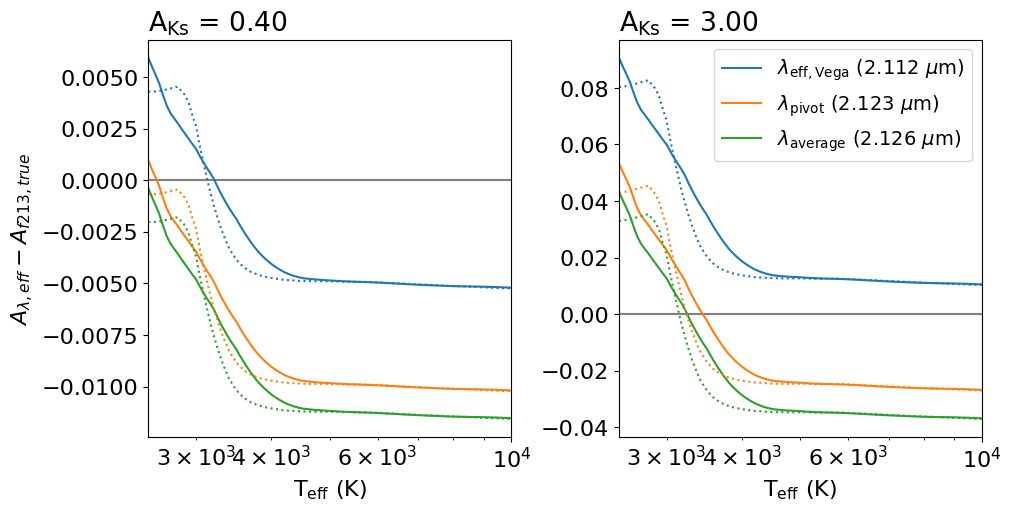

In [95]:
fig,ax = ecf.plot_extinction_difference('f213', [0.4,3.0])

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f146_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f146_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
saving figure


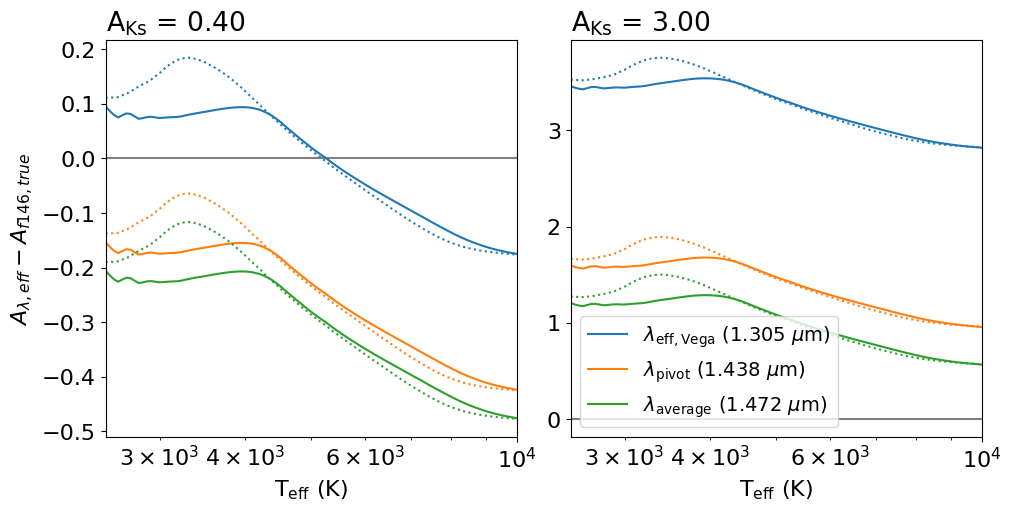

In [96]:
fig,ax = ecf.plot_extinction_difference('f146', [0.4,3.0])

In [2]:
import pysynphot

/Users/mhuston/anaconda3/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /Users/mhuston/NotBacked/spisea_data/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [6]:
evo_model = evolution.MISTv1(version=1.2,synthpop_extension=True) 
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawSODC(Rv=2.5)
wd_atm_func = atmospheres.get_wd_atmosphere

In [7]:
def get_filt(flt):
    flt_name = 'roman,wfi,'+flt
    filt = synthetic.get_filter_info(flt_name)
    return filt

def get_eff_lam(flt):
    flt_name = 'roman,wfi,'+flt
    filt = synthetic.get_filter_info(flt_name)
    obs = pysynphot.Observation(pysynphot.Vega, filt).efflam()
    assert str(filt.waveunits) == 'angstrom'
    return obs

def get_piv_lam(flt):
    flt_name = 'roman,wfi,'+flt
    filt = synthetic.get_filter_info(flt_name)
    obs = filt.pivot()
    assert str(filt.waveunits) == 'angstrom'
    return obs

def get_avg_lam(flt):
    flt_name = 'roman,wfi,'+flt
    filt = synthetic.get_filter_info(flt_name)
    obs = filt.avgwave()
    assert str(filt.waveunits) == 'angstrom'
    return obs

In [8]:
filts = ['f062','f087','f106','f129','f158','f184','f213','f146']
filt_avgs = [get_avg_lam(flt) for flt in filts]
Afiltavg_AKs = red_law.SODC(np.array(filt_avgs)*1e-4,1)
Afilteff_AKs = red_law.SODC(np.array([get_eff_lam(flt) for flt in filts])*1e-4,1)
Afiltpiv_AKs = red_law.SODC(np.array([get_piv_lam(flt) for flt in filts])*1e-4,1)

(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f062_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f087_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f106_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f129_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_f158_003_syn.fits) does not have a defined binset in the wavecat table. The waveset of the spectrum will be used instead.
(/Users/mhuston/NotBacked/spisea_data/cdbs/comp/nonhst/roman_wfi_

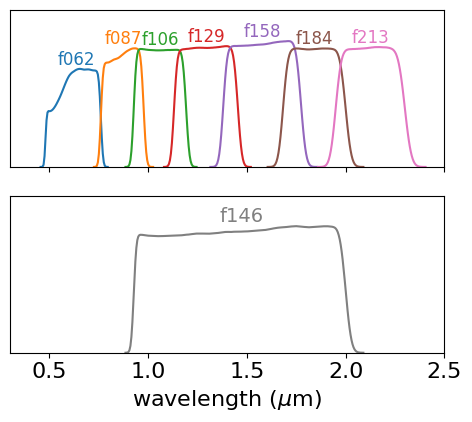

In [9]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True, figsize=(5,4.5))#,gridspec_kw={"hspace":0.1})
j=0
# for i,flt_str in enumerate(['Z','Y','J','H','Ks']):
#     flt = synthetic.get_filter_info('vista,'+flt_str)
#     ax[0].plot(flt.wave/1e4, flt.throughput, c="C"+str([1,2,3,4,6][i]))
#     ax[0].text(flt.pivot()/1e4, np.max(flt.throughput), flt_str, c="C"+str([1,2,3,4,6][i]),
#             ha='center', va='bottom', fontsize=14)
for i,flt_str in enumerate(filts[:-1]):
    flt = get_filt(flt_str)
    ax[0].plot(flt.wave/1e4, flt.throughput, c="C"+str(i))
    ax[0].text(filt_avgs[i]/1e4, np.max(flt.throughput), flt_str, c="C"+str(i),
            ha='center', va='bottom', fontsize=12)
flt = get_filt('F146')
ax[1].plot(flt.wave/1e4, flt.throughput, c="gray")
ax[1].text(filt_avgs[-1]/1e4, np.max(flt.throughput), "f146", c="gray",
            ha='center', va='bottom', fontsize=14)    
    
ax[1].set_xlabel(r'wavelength ($\mu$m)')
ax[0].set_ylim(0,0.85)
ax[1].set_ylim(0,0.85)
ax[0].set_xlim(0.3,2.5)
for axi in ax:
    axi.set_yticks([])
fig.tight_layout()
fig.savefig('figures/roman_filters_only.pdf')

In [64]:
spec1 = atm_func(metallicity=0, temperature=2_500, gravity=4.5)
spec2 = atm_func(metallicity=0, temperature=10_000, gravity=2.0)

In [65]:
spec1.fluxunits

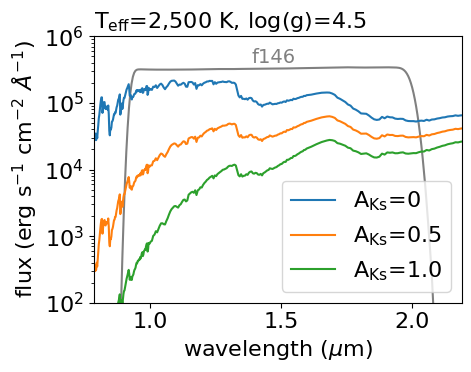

In [66]:
flt = get_filt('F146')
filt_scale = 5e5
plt.figure(figsize=(5,4))
plt.plot(flt.wave/1e4, flt.throughput*filt_scale, c="gray")
plt.text(filt_avgs[-1]/1e4, np.max(flt.throughput)*filt_scale, "f146", c="gray",
            ha='center', va='bottom', fontsize=14)    
plt.plot(spec1.wave/1e4, spec1.flux, label=r'A$_{\rm Ks}$=0')
for A_Ks in [0.5,1.0]: #,1.5,2.0]:
    red = red_law.reddening(A_Ks).resample(spec1.wave)
    plt.plot(spec1.wave/1e4, (spec1*red).flux, label=fr'A$_{{\rm Ks}}$={A_Ks:.1f}')
plt.xlim(min(flt.wave/1e4)-0.1,max(flt.wave/1e4)+0.1)
plt.ylim(1e2,1e6)
plt.yscale('log')
plt.legend(loc=4)
plt.xlabel(r'wavelength ($\mu$m)')
plt.ylabel(r'flux (erg s$^{−1}$ cm$^{−2}$ $\AA^{−1}$)')
plt.title(r'T$_{\rm eff}$=2,500 K, log(g)=4.5', fontsize=16, loc='left')
plt.tight_layout()
plt.savefig('figures/ext_spectrum1.png')
plt.savefig('figures/ext_spectrum1.pdf')

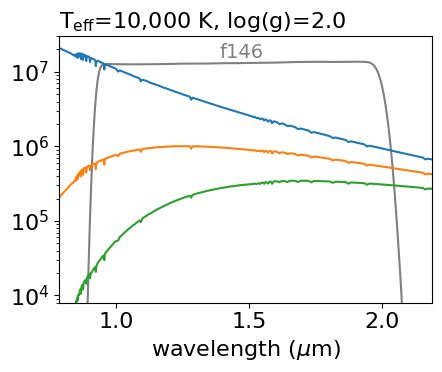

In [67]:
flt = get_filt('F146')
filt_scale = 2e7
plt.figure(figsize=(4.7,4))
plt.plot(flt.wave/1e4, flt.throughput*filt_scale, c="gray")
plt.text(filt_avgs[-1]/1e4, np.max(flt.throughput)*filt_scale, "f146", c="gray",
            ha='center', va='bottom', fontsize=14)    
plt.plot(spec2.wave/1e4, spec2.flux, label=r'A$_{\rm Ks}$=0')
for A_Ks in [0.5,1.0]: #,1.5,2.0]:
    red = red_law.reddening(A_Ks).resample(spec2.wave)
    plt.plot(spec2.wave/1e4, (spec2*red).flux, label=fr'A$_{{\rm Ks}}$={A_Ks:.1f}')
plt.xlim(min(flt.wave/1e4)-0.1,max(flt.wave/1e4)+0.1)
plt.ylim(8e3,3e7)
plt.yscale('log')
#plt.legend(loc=4)
plt.xlabel(r'wavelength ($\mu$m)')
#plt.ylabel(r'flux (erg s$^{−1}$ cm$^{−2}$ $\AA^{−1}$)')
plt.title(r'T$_{\rm eff}$=10,000 K, log(g)=2.0', fontsize=16, loc='left')
plt.tight_layout()
plt.savefig('figures/ext_spectrum2.png')
plt.savefig('figures/ext_spectrum2.pdf')

0.03